# AI Productivity: Exploratory Data Analysis


In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', None)

## Initial Inspection

In [237]:
df = pd.read_csv('ai_productivity_dataset_final.csv')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 3,248   Columns: 34


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,scope_change_flag,pricing_model,created_at,delivered_at,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,errors,rework_hours,outcome_score,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.00,high,0,hourly,2025-11-20,2025-11-25,10.00,0,7.63,5.14,0.75,True,1,1,2.10,69.93,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.00,medium,0,fixed,2026-01-24,2026-01-26,7.00,0,9.52,8.22,0.12,False,1,1,4.48,82.79,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.00,medium,0,fixed,2025-09-16,2025-09-23,5.00,1,8.45,6.15,0.37,True,2,0,2.71,76.40,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.00,low,0,hourly,2025-11-06,2025-11-09,3.00,0,28.35,24.22,0.07,False,4,1,0.00,NaN,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.00,low,0,fixed,2026-05-02,2026-05-06,7.00,0,5.93,4.44,0.20,True,2,2,0.84,NaN,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


3,248 rows and 34 columns loaded. Fields cover task metadata (team, type, seniority), financial outcomes (revenue, cost, profit), AI usage, quality scores, and operational flags.

In [238]:
df.describe(include='object').T

/var/folders/44/03mcwhz17xd0nk52ybzc8rqr0000gn/T/ipykernel_16985/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
task_id,3248,3200,T00010,2
client,3248,28,Client_G,415
project_id,3248,64,P028,77
client_tier,3248,3,mid,1514
team,3248,15,Content,803
task_type,3248,29,design,456
seniority,3248,3,mid,1296
deadline_pressure,3248,3,medium,1482
pricing_model,3248,3,hourly,1561
created_at,3248,330,2026-03-27,22


In [239]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
task_complexity_score,3248.00,2.87,1.20,1.00,2.00,3.00,4.00,5.00
brief_quality_score,3179.00,3.18,1.21,1.00,2.00,3.00,4.00,5.00
scope_change_flag,3248.00,0.14,0.35,0.00,0.00,0.00,0.00,1.00
sla_days,3212.00,5.01,2.52,2.00,3.00,5.00,7.00,10.00
sla_breach,3248.00,0.40,0.49,0.00,0.00,0.00,1.00,1.00
hours_spent,3248.00,13.06,11.56,0.02,7.91,11.11,15.34,263.60
billable_hours,3166.00,8.43,4.78,-1.90,5.08,7.54,10.69,47.02
ai_usage_pct,3104.00,0.36,0.20,0.00,0.20,0.34,0.50,0.93
revisions,3248.00,3.01,1.80,0.00,2.00,3.00,4.00,11.00
errors,3248.00,1.01,1.04,0.00,0.00,1.00,2.00,7.00


In [240]:
df.isna().sum()

task_id                    0
client                     0
project_id                 0
client_tier                0
team                       0
task_type                  0
seniority                  0
task_complexity_score      0
brief_quality_score       69
deadline_pressure          0
scope_change_flag          0
pricing_model              0
created_at                 0
delivered_at              38
sla_days                  36
sla_breach                 0
hours_spent                0
billable_hours            82
ai_usage_pct             144
ai_assisted                0
revisions                  0
errors                     0
rework_hours              72
outcome_score            133
revenue                    0
cost                       0
profit                     0
created_by                 0
updated_at                 0
task_status                0
workflow_stage             0
jira_ticket              339
legacy_ai_flag             0
content_version            0
dtype: int64

### Key findings from `.describe()`

**Impossible values** to fix before any analysis:
`billable_hours` has a minimum of −1.9. Negative billable hours are not physically possible, likely billing corrections or data entry errors.
`profit` reaches −€8,510. While negative profit is a valid business outcome, the magnitude relative to median revenue (~€966) warrants careful inspection.

**Severe outliers** to handle before modelling:
`hours_spent` peaks at 263.6 h versus a median of 11.1 h, over 23× the typical task. `rework_hours` peaks at 57.5 h versus a median of 1.8 h. Both show extreme right tails that will distort regression coefficients.

**Missing data on the main predictor:**
`ai_usage_pct` has 144 missing values (4.4%). Since this is our main variable of interest, we will exclude these rows from regression rather than impute.

**High SLA breach rate:**
`sla_breach` averages 0.40, meaning 40% of tasks breached their SLA. A strong candidate variable to cross with AI usage.

**Dirty categorical columns** requiring normalisation:
`team` has 15 recorded values for 4 real teams. `task_type` has 29 for 7 real types. Both suffer from casing variants and typos. `legacy_ai_flag` carries a third value `"unknown"` in 339 rows despite being a boolean field.

## Data Quality and Cleaning
Each issue is inspected, explained, then resolved immediately below.

### Impossible Values

#### Negative `billable_hours`

In [241]:
neg_bill = df[df['billable_hours'] < 0].copy()

print(f"Rows with negative billable_hours : {len(neg_bill)}")
print(f"Value range                       : {neg_bill['billable_hours'].min():.2f}  to  {neg_bill['billable_hours'].max():.2f}")
print(f"Still profitable                  : {(neg_bill['profit'] > 0).sum()}")
print(f"Also loss-making                  : {(neg_bill['profit'] < 0).sum()}")

Rows with negative billable_hours : 17
Value range                       : -1.90  to  -0.28
Still profitable                  : 12
Also loss-making                  : 5


Only 17 rows, values between −0.28 h and −1.90 h. Most of these tasks remain profitable, suggesting billing corrections or inter-project hour transfers rather than data entry errors. Since negative hours carry no meaningful interpretation, we cap them at zero.

In [242]:
df['billable_hours'] = df['billable_hours'].clip(lower=0)

17 rows corrected. `billable_hours` minimum is now 0. No rows removed.

#### Negative `profit`

In [243]:
neg_profit = df[df['profit'] < 0].copy()

print(f"Rows with negative profit : {len(neg_profit)} ({len(neg_profit)/len(df)*100:.1f}% of dataset)")


Rows with negative profit : 817 (25.2% of dataset)


817 tasks (25%) are loss-making, with losses ranging from −€1.60 to −€8,510. These are valid business outcomes and among the most informative rows for our analysis. We do not remove them. We add a binary flag `is_loss` to make this directly usable as a feature or target variable.

In [244]:
df['is_loss'] = (df['profit'] < 0).astype(int)

`is_loss` column added. 817 tasks (25%) flagged as loss-making. All rows kept.

#### `rework_hours` > `hours_spent`
A task cannot have more rework hours than total hours spent on it. Rows that violate this constraint are logically impossible and cannot be corrected without the original data: we inspect them before deciding.

In [245]:
impossible_rework = df[df['rework_hours'] > df['hours_spent']].copy()

print(f"Rows where rework_hours > hours_spent : {len(impossible_rework)}")
print(f"\nrework_hours vs hours_spent for these rows:")
print(impossible_rework[['task_id', 'hours_spent', 'rework_hours', 'team', 'task_type', 'seniority', 'ai_usage_pct', 'profit']].to_string())

print(f"\nDifference (rework - hours_spent):")
diff = (impossible_rework['rework_hours'] - impossible_rework['hours_spent'])
print(diff.describe())

Rows where rework_hours > hours_spent : 67

rework_hours vs hours_spent for these rows:
     task_id  hours_spent  rework_hours        team task_type seniority  ai_usage_pct   profit
132   T00132         0.02          0.80     Content       dev       mid          0.37  1168.78
136   T00136        13.49         21.55       Media   release    senior           NaN   519.28
146   T00146        13.04         15.23      Design       dev    junior          0.59  1187.14
165   T00165        31.76         56.45       Media   release    senior          0.31  -233.74
305   T00305        16.04         19.85      Design    report       mid          0.80  3022.44
354   T00354         7.23         26.00     Content    design    senior          0.19   188.45
359   T00359         0.19          0.98       Media       dev       mid          0.16   356.70
376   T00376         1.93          2.16      Design    Ticket       mid          0.33   258.59
465   T00465         8.47         57.52      Design    re

The exact meaning of `hours_spent` and `rework_hours` is ambiguous from the data alone: it is unclear whether `hours_spent` represents total time including rework, or only initial delivery time excluding it. This distinction changes whether the 67 rows are errors or valid entries. **These columns must be clarified with the data owner or supervisor before any cleaning decision is made.**

#### `ai_assisted` and `ai_usage_pct` disagreement

In [246]:
ai_assisted_but_0_pct = (df.loc[(df["ai_assisted"] == False) & df["ai_usage_pct"] > 0].shape[0])
not_ai_assisted_but_pos_pct = df.loc[(df["ai_assisted"] == True) & df["ai_usage_pct"] == 0].shape[0]

print(f"#{ai_assisted_but_0_pct} cases where the ai_assisted flag is set False but the ai_usage_pct is a number greater than 0")
print(f"#{not_ai_assisted_but_pos_pct} cases where the ai_usage_pct flag is set to True but the ai_assisted is 0")
print(f"Together they constitute {(ai_assisted_but_0_pct + not_ai_assisted_but_pos_pct) / df.shape[0] * 100:.2f}% of the dataset")

#655 cases where the ai_assisted flag is set False but the ai_usage_pct is a number greater than 0
#801 cases where the ai_usage_pct flag is set to True but the ai_assisted is 0
Together they constitute 44.83% of the dataset


Discrepancies between the `ai_assisted` boolean value and the `ai_usage_pct` column. There are 
- 639 cases where the `ai_assisted` flag is set to `False` but the `ai_usage_pct` is a number greater than 0
- 782 

Need to determine how to handle them.

### Categorical Normalisation

In [247]:
for col in ['team', 'task_type', 'legacy_ai_flag']:
    counts = df[col].value_counts()
    print(f"── {col}  ({counts.nunique()} unique values)")
    print(counts.to_string())
    print()

── team  (14 unique values)
team
Content       803
Media         781
Design        761
SEO           747
seo            29
media          25
content        22
design         19
SEO            18
DESIGN         12
Paid Media      8
Contennt        8
MEDIA           7
Desgn           6
CONTENT         2

── task_type  (18 unique values)
task_type
design            456
ad                453
ticket            451
report            447
article           446
dev               435
release           421
article_task       15
ad_task            11
relese             11
ticket_task        11
design_task        10
Ticket              8
Report              8
release_task        8
report_task         7
Design              7
Ad                  6
development         5
creative            5
dev_task            4
repport             4
paid_ad             4
artcle              3
support_ticket      3
Release             3
blog_article        3
DEV                 2
Article             1

── legacy_ai_f

`team` collapses from 15 to 4 real values once casing and typos are normalised. `task_type` collapses from 29 to 7 after lowercasing, stripping the `_task` suffix, and mapping typos and aliases (`artcle`, `repport`, `relese`, `creative`, `blog_article`, `paid_ad`, `support_ticket`, `development`). `legacy_ai_flag` carries an unexpected third value `"unknown"` in 339 rows, treated separately below.

In [248]:
team_mapping = {
    'content': 'Content', 'CONTENT': 'Content', 'Contennt': 'Content',
    'media': 'Media', 'MEDIA': 'Media', 'Paid Media': 'Media',
    'seo': 'SEO', 'SEO ': 'SEO',
    'design': 'Design', 'DESIGN': 'Design', 'Desgn': 'Design'
}
df['team'] = df['team'].replace(team_mapping)

In [249]:
def consolidate_task_type(val):
    if pd.isna(val): 
        return "unknown"
    
    v = str(val).lower().strip()
    v = v.replace('_task', '')          # strip common suffix first

    if 'article' in v or 'artcle' in v or 'blog' in v:
        return 'article'
    if 'design' in v or 'creative' in v:
        return 'design'
    if 'ticket' in v or 'support' in v:
        return 'ticket'
    if 'report' in v or 'repport' in v:
        return 'report'
    if 'ad' in v:
        return 'ad'
    if 'dev' in v:
        return 'dev'
    if 'rele' in v:
        return 'release'
        
    return v

df['task_type'] = df['task_type'].apply(consolidate_task_type)

In [250]:
print("Final task_type distribution:")
print(df['task_type'].str.capitalize().value_counts().to_string())

print("\nFinal team distribution:")
print(df['team'].value_counts().to_string())

Final task_type distribution:
task_type
Design     478
Ad         474
Ticket     473
Article    468
Report     466
Dev        446
Release    443

Final team distribution:
team
Content    835
Media      821
Design     798
SEO        794


Both columns are now clean and consistent: `team` has 4 categories, `task_type` has 7.

#### `legacy_ai_flag` Unknown Values

In [251]:
df['legacy_ai_flag'] = df['legacy_ai_flag'].replace('unknown', np.nan).map({"true": True, "false": False})

print(df['legacy_ai_flag'].value_counts(dropna=False).to_string())

legacy_ai_flag
False    1458
True     1451
NaN       339


339 `"unknown"` entries replaced with `NaN`. Column is now strictly boolean with missing values handled consistently.

### Duplicates

In [252]:
dup_mask = df.duplicated(subset='task_id', keep=False)
dup_rows = df[dup_mask].sort_values(['task_id', 'updated_at'])

print(f"Duplicated task_ids : {dup_rows['task_id'].nunique()}")
print(f"Rows involved       : {len(dup_rows)}")


Duplicated task_ids : 48
Rows involved       : 96


In [253]:
df['updated_at'] = pd.to_datetime(df['updated_at'])

# We decided to keep the most recent record per task_id (based on updated_at)
df = (
    df.sort_values('updated_at', ascending=False)
      .drop_duplicates(subset='task_id', keep='first')
      .reset_index(drop=True)
)

assert df['task_id'].is_unique
print(f"Shape after deduplication: {df.shape}")

Shape after deduplication: (3200, 35)


48 `task_id` had two versions each. The most recent record per task (by `updated_at`) was kept. Dataset is now 3,200 rows with every `task_id` unique.

### Date Validation

In [254]:
df['created_at']  = pd.to_datetime(df['created_at'],  errors='coerce')
df['delivered_at'] = pd.to_datetime(df['delivered_at'], errors='coerce')

cutoff_date = pd.Timestamp('2026-03-28')

logic_errors  = df[df['delivered_at'] < df['created_at']]
future_errors = df[df['created_at'] > cutoff_date]

print(f"Validation Summary:")
print(f"1. Logic errors (delivered before created) : {len(logic_errors)} rows")
print(f"2. Future created_at (after {cutoff_date.date()})     : {len(future_errors)} rows")
print(f"3. Null delivered_at                        : {df['delivered_at'].isna().sum()} rows")

# Drop the 14 rows where delivered_at < created_at — logically impossible, unrecoverable
df = df[df['delivered_at'] >= df['created_at']].reset_index(drop=True)
print(f"\nRows after removing logic errors: {df.shape[0]}")

Validation Summary:
1. Logic errors (delivered before created) : 14 rows
2. Future created_at (after 2026-03-28)     : 522 rows
3. Null delivered_at                        : 38 rows

Rows after removing logic errors: 3148


Dates parsed to datetime. 14 logic errors (delivered before created) removed from `df`. 522 tasks with future `created_at` retained as valid scheduled entries since their financial and AI usage fields are fully populated.

#### Missing `delivered_at`

In [255]:
missing_delivered = df[df['delivered_at'].isna()].copy()

print(f"Rows with null delivered_at : {len(missing_delivered)}")
print(f"\ntask_status breakdown:")
print(missing_delivered['task_status'].value_counts().to_string())
print(f"\nAre the other key fields populated?")
print(missing_delivered[['profit', 'hours_spent', 'ai_usage_pct', 'outcome_score']].notna().sum())

Rows with null delivered_at : 0

task_status breakdown:
Series([], )

Are the other key fields populated?
profit           0
hours_spent      0
ai_usage_pct     0
outcome_score    0
dtype: int64


25 rows carry a non-delivered status so a null `delivered_at` is expected behaviour. 13 rows are marked `delivered` but have no date recorded, a data entry omission we cannot recover. All 38 are kept. `delivered_at` is not used as a feature in the core analysis so the nulls are left as `NaN`.

## Visualization

In [256]:
PRIMARY = "#355C73"
MID = "#8FA3B5"
LIGHT = "#DCE4EA"
ACCENT = "#5F7F76"
RISK = "#B5614C"
MUTED = "#98A2B3"

band_order = ['low  (0–25%)', 'medium  (25–50%)', 'high  (50%+)']
band_palette = {
    band_order[0]: LIGHT,
    band_order[1]: MID,
    band_order[2]: PRIMARY,
}
band_colors = [band_palette[b] for b in band_order]
heatmap_cmap = sns.diverging_palette(245, 20, s=65, l=45, as_cmap=True)

sns.set_theme(style="white", context="notebook")
sns.set_palette([PRIMARY, MID, ACCENT, RISK])

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D0D5DD",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.color": "#667085",
    "ytick.color": "#667085",
    "legend.frameon": False,
})

df['ai_band'] = pd.cut(
    df['ai_usage_pct'],
    bins=[0, 0.25, 0.50, 1.01],
    labels=band_order,
    include_lowest=True
)
print(df['ai_band'].value_counts().sort_index())

def finish_ax(ax):
    sns.despine(ax=ax, top=True, right=True)
    return ax


ai_band
low  (0–25%)        1039
medium  (25–50%)    1226
high  (50%+)         742
Name: count, dtype: int64


### Distributions of Core Variables

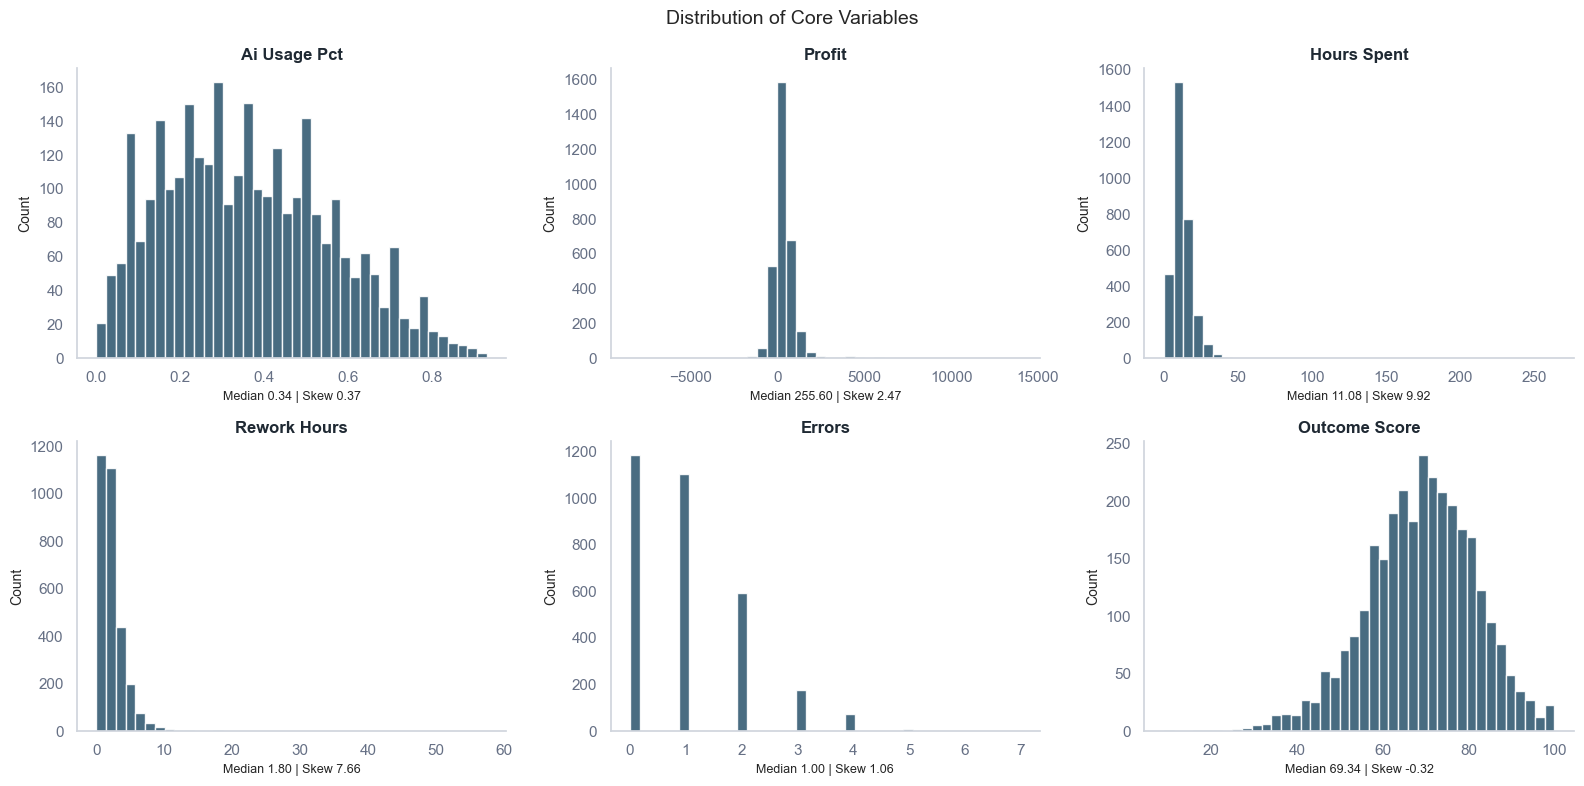

In [257]:
core_vars = ['ai_usage_pct', 'profit', 'hours_spent', 'rework_hours', 'errors', 'outcome_score']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axes.flat, core_vars):
    data = df[var].dropna()
    ax.hist(data, bins=40, color=PRIMARY, edgecolor='white', alpha=0.9)
    ax.set_title(var.replace('_', ' ').title())
    ax.set_xlabel(f'Median {data.median():.2f} | Skew {data.skew():.2f}', fontsize=9)
    ax.set_ylabel('Count')
    finish_ax(ax)

plt.suptitle('Distribution of Core Variables', fontsize=14)
plt.tight_layout()
plt.show()


`ai_usage_pct` is unevenly distributed: the low band holds 1,039 tasks, medium 1,226, and high only 742 — intensive AI use is the least common. `profit` and `hours_spent` are heavily right-skewed (medians well below means), meaning positive outliers will pull regression coefficients upward if not handled. `outcome_score` is approximately normal around 69.

### AI Usage vs Outcomes — Decile Means ± 95% CI (Q1 & Q2)

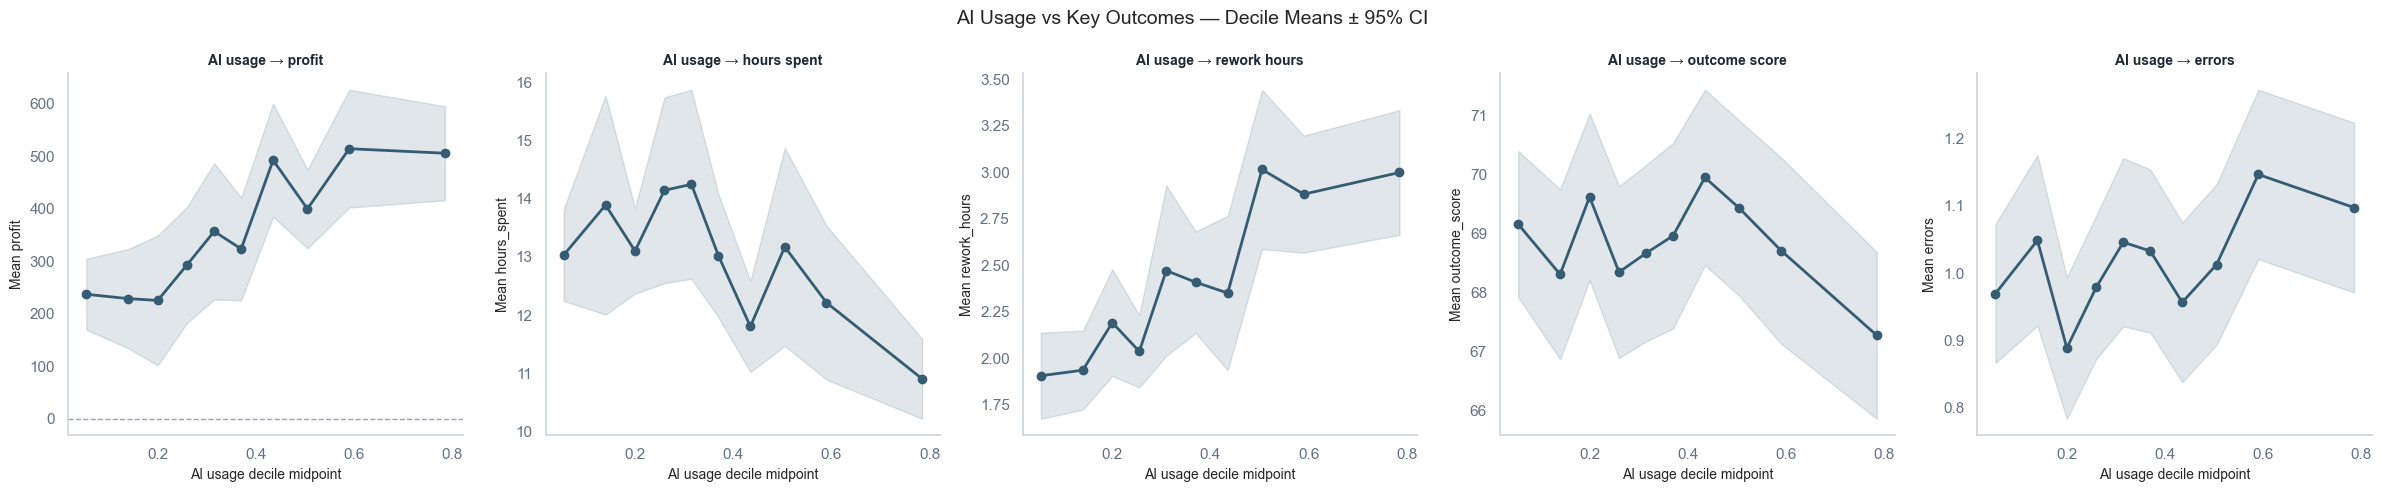

In [258]:
outcome_pairs = [
    ('profit',        'AI usage → profit'),
    ('hours_spent',   'AI usage → hours spent'),
    ('rework_hours',  'AI usage → rework hours'),
    ('outcome_score', 'AI usage → outcome score'),
    ('errors',        'AI usage → errors'),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, (var, title) in zip(axes, outcome_pairs):
    data = df.dropna(subset=['ai_usage_pct', var]).copy()
    data['ai_bin'] = pd.qcut(data['ai_usage_pct'], q=10, duplicates='drop')
    binned = data.groupby('ai_bin', observed=True)[var].agg(['mean', 'sem'])
    midpoints = [iv.mid for iv in binned.index]
    means = binned['mean']
    ci = 1.96 * binned['sem']

    ax.plot(midpoints, means, marker='o', linewidth=2, color=PRIMARY)
    ax.fill_between(midpoints, means - ci, means + ci, alpha=0.15, color=PRIMARY)
    if var == 'profit':
        ax.axhline(0, color=MUTED, linewidth=1, linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('AI usage decile midpoint')
    ax.set_ylabel(f'Mean {var}')
    finish_ax(ax)

plt.suptitle('AI Usage vs Key Outcomes — Decile Means ± 95% CI', fontsize=14)
plt.tight_layout()
plt.show()


The `profit` curve is **monotonically increasing** (~€225 in the lowest decile, ~€514 in the highest) — no inverted-U at the aggregate level. The largest gain occurs above 40% AI usage. `rework_hours` rises slightly alongside AI usage, but not enough to reverse the profit trend. The mechanism is not "AI destroys value beyond a threshold" but rather "AI creates value while rework grows in parallel, partially offsetting it".

### Outcome Distributions and Risk Rates by AI Band (Q3)

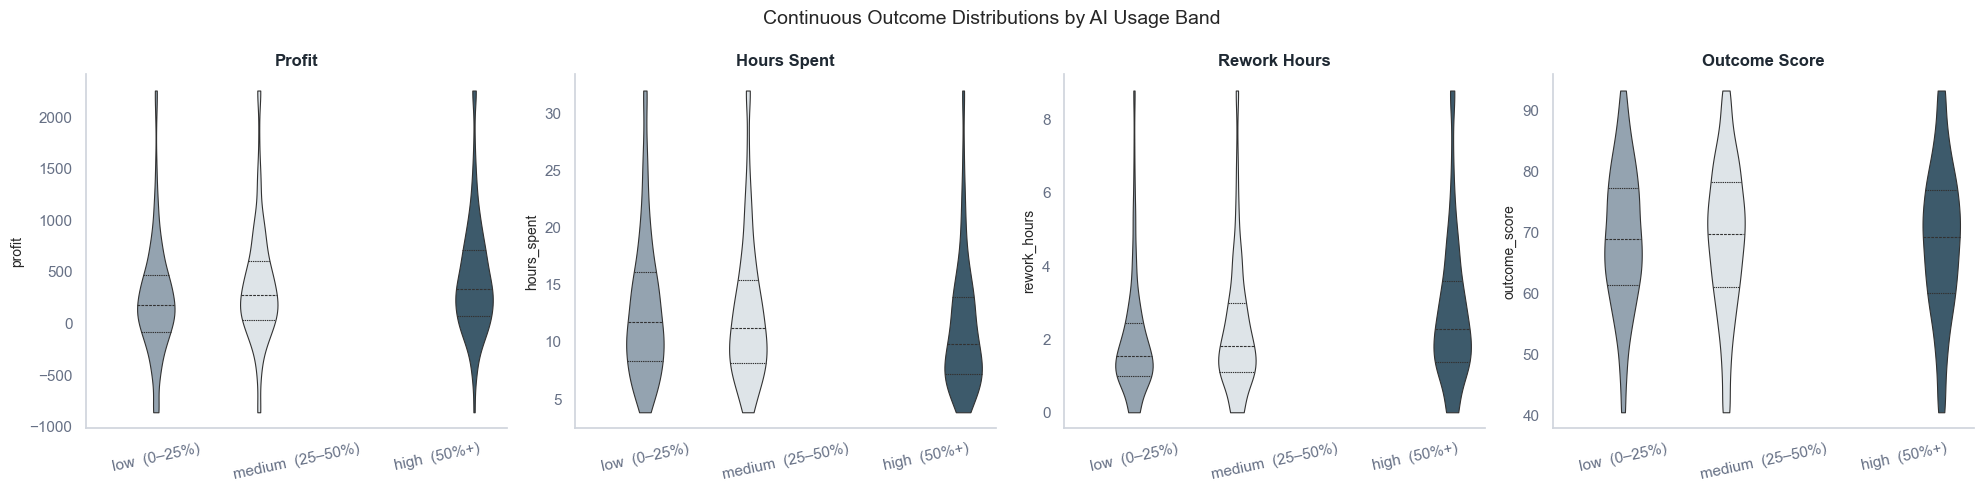

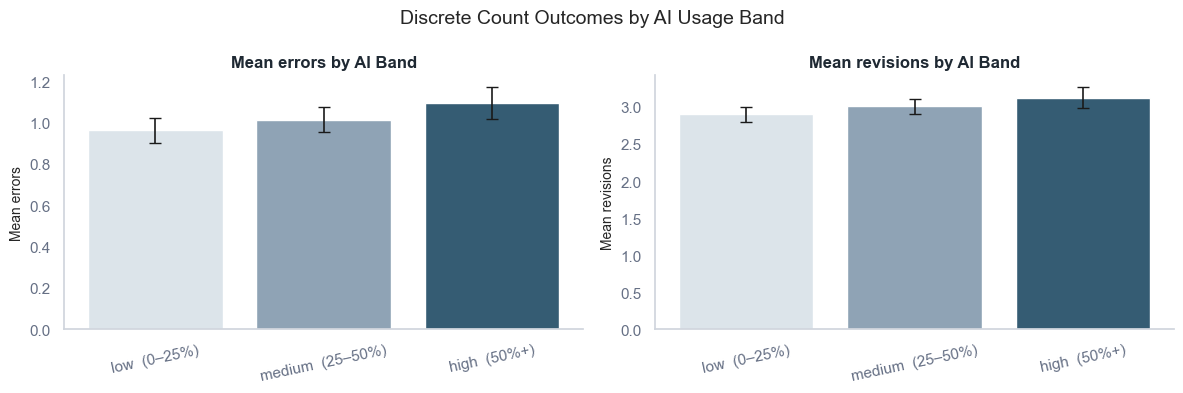

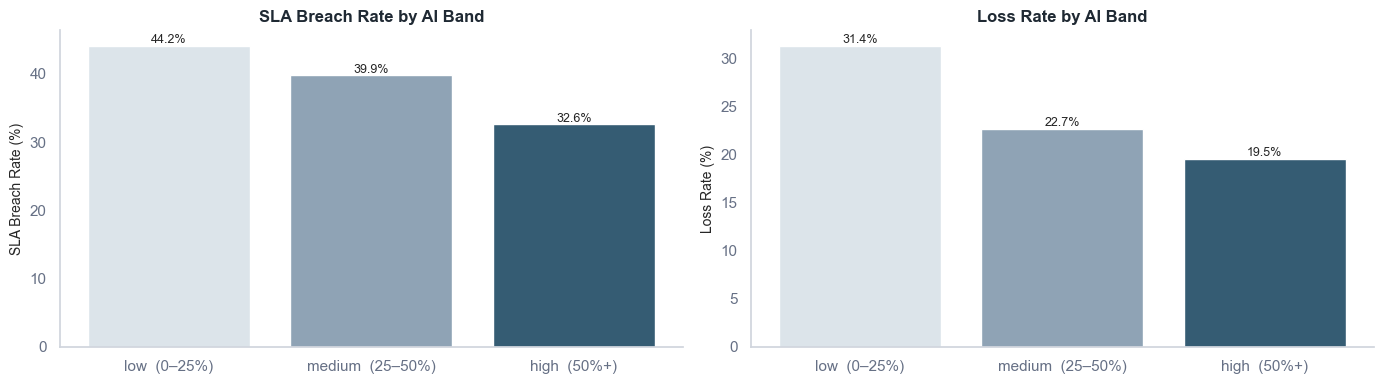

In [259]:
df_bands = df.dropna(subset=['ai_band'])

# Violin plots — only for continuous outcomes
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var in zip(axes, ['profit', 'hours_spent', 'rework_hours', 'outcome_score']):
    lo, hi = df[var].quantile(0.02), df[var].quantile(0.98)
    plot_data = df_bands.dropna(subset=[var]).copy()
    plot_data[var] = plot_data[var].clip(lo, hi)
    sns.violinplot(
        data=plot_data, x='ai_band', y=var, hue='ai_band', order=band_order, hue_order=band_order,
        palette=band_palette, ax=ax, inner='quartile', cut=0, linewidth=0.8, legend=False
    )
    ax.set_title(var.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=12)
    finish_ax(ax)

plt.suptitle('Continuous Outcome Distributions by AI Usage Band', fontsize=14)
plt.tight_layout()
plt.show()

# Bar charts with 95% CI — for discrete count outcomes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, var in zip(axes, ['errors', 'revisions']):
    stats = df_bands.groupby('ai_band', observed=True)[var].agg(['mean', 'sem']).reindex(band_order)
    ax.bar(
        band_order, stats['mean'], yerr=1.96 * stats['sem'],
        color=band_colors, edgecolor='white', capsize=4, error_kw={'elinewidth': 1.2}
    )
    ax.set_title(f'Mean {var} by AI Band')
    ax.set_ylabel(f'Mean {var}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=12)
    finish_ax(ax)

plt.suptitle('Discrete Count Outcomes by AI Usage Band', fontsize=14)
plt.tight_layout()
plt.show()

# SLA breach rate and loss rate side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (col, label) in zip(axes, [('sla_breach', 'SLA Breach Rate'), ('is_loss', 'Loss Rate')]):
    rate = df_bands.groupby('ai_band', observed=True)[col].mean().reindex(band_order).mul(100)
    bars = ax.bar(band_order, rate, color=band_colors, edgecolor='white')
    ax.set_ylabel(f'{label} (%)')
    ax.set_title(f'{label} by AI Band')
    for bar, val in zip(bars, rate):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
    finish_ax(ax)

plt.tight_layout()
plt.show()


Against the initial hypothesis, both SLA breach rate and loss rate **decrease** as the AI band increases (SLA breach: 44% → 40% → 33%; loss rate: 31% → 23% → 19%). Mean profit rises from €232 to €474. At the aggregate level, higher AI use improves operational performance — however, errors and revisions increase slightly (0.96→1.09 and 2.90→3.12), indicating a quality cost that the models will need to quantify.

### Speed–Quality Trade-off by AI Band

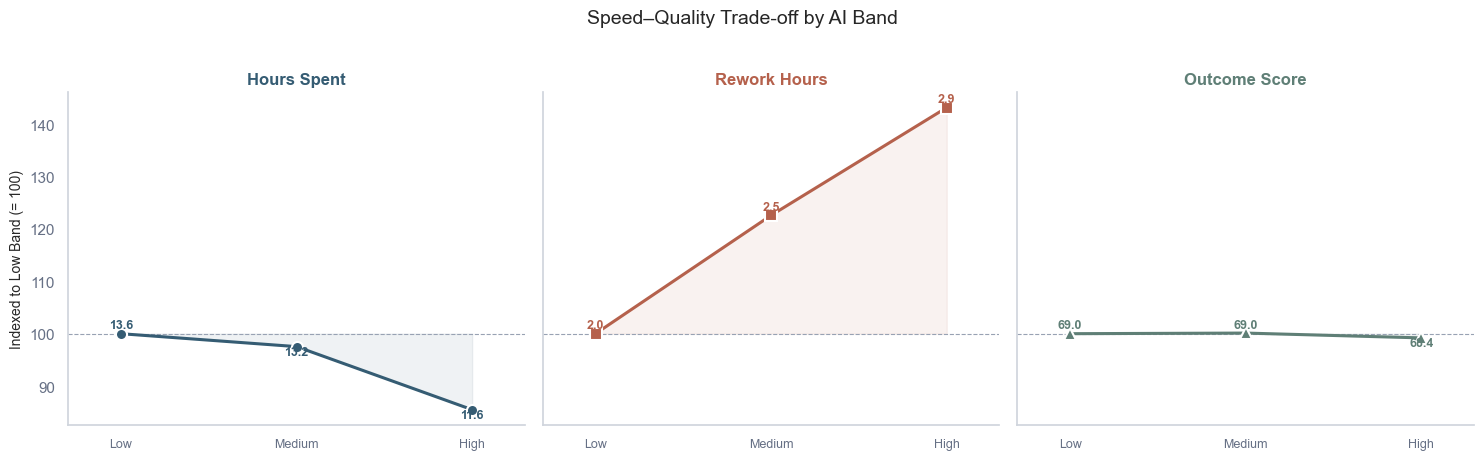

In [260]:
speed_quality = (
    df_bands.groupby('ai_band', observed=True)
    [['hours_spent', 'rework_hours', 'outcome_score']]
    .mean()
    .reindex(band_order)
)

# Index each metric to the low band (= 100) so all three share one scale
indexed = speed_quality.div(speed_quality.iloc[0]).mul(100)

labels = ['Hours Spent', 'Rework Hours', 'Outcome Score']
colors = [PRIMARY, RISK, ACCENT]
icons  = ['o', 's', '^']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, col, label, color, icon in zip(axes, indexed.columns, labels, colors, icons):
    vals = indexed[col]
    raw  = speed_quality[col]

    ax.plot(range(3), vals, marker=icon, color=color, linewidth=2.2,
            markersize=8, markeredgecolor='white', markeredgewidth=1.5, zorder=3)
    ax.fill_between(range(3), 100, vals, alpha=0.08, color=color)
    ax.axhline(100, color=MUTED, linewidth=0.8, linestyle='--', zorder=1)

    for i, (v, r) in enumerate(zip(vals, raw)):
        offset = 4 if v >= 100 else -6
        ax.annotate(f'{r:.1f}', (i, v), textcoords='offset points',
                    xytext=(0, offset), ha='center', fontsize=9, color=color, fontweight='bold')

    ax.set_title(label, fontsize=12, color=color, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=9)
    ax.set_xlim(-0.3, 2.3)
    finish_ax(ax)

axes[0].set_ylabel('Indexed to Low Band (= 100)', fontsize=10)

plt.suptitle('Speed–Quality Trade-off by AI Band', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

`hours_spent` drops modestly (13.6h → 11.6h) with high AI use, while `rework_hours` rises (2.0h → 2.9h) — the trade-off exists but is asymmetric: ~2h saved, ~0.9h added as rework, for a net gain of roughly 1h. `outcome_score` remains essentially flat (~69 across all bands). AI does not improve perceived quality, but it does not meaningfully degrade it either.

### Segmentation by Task Context (Q4)

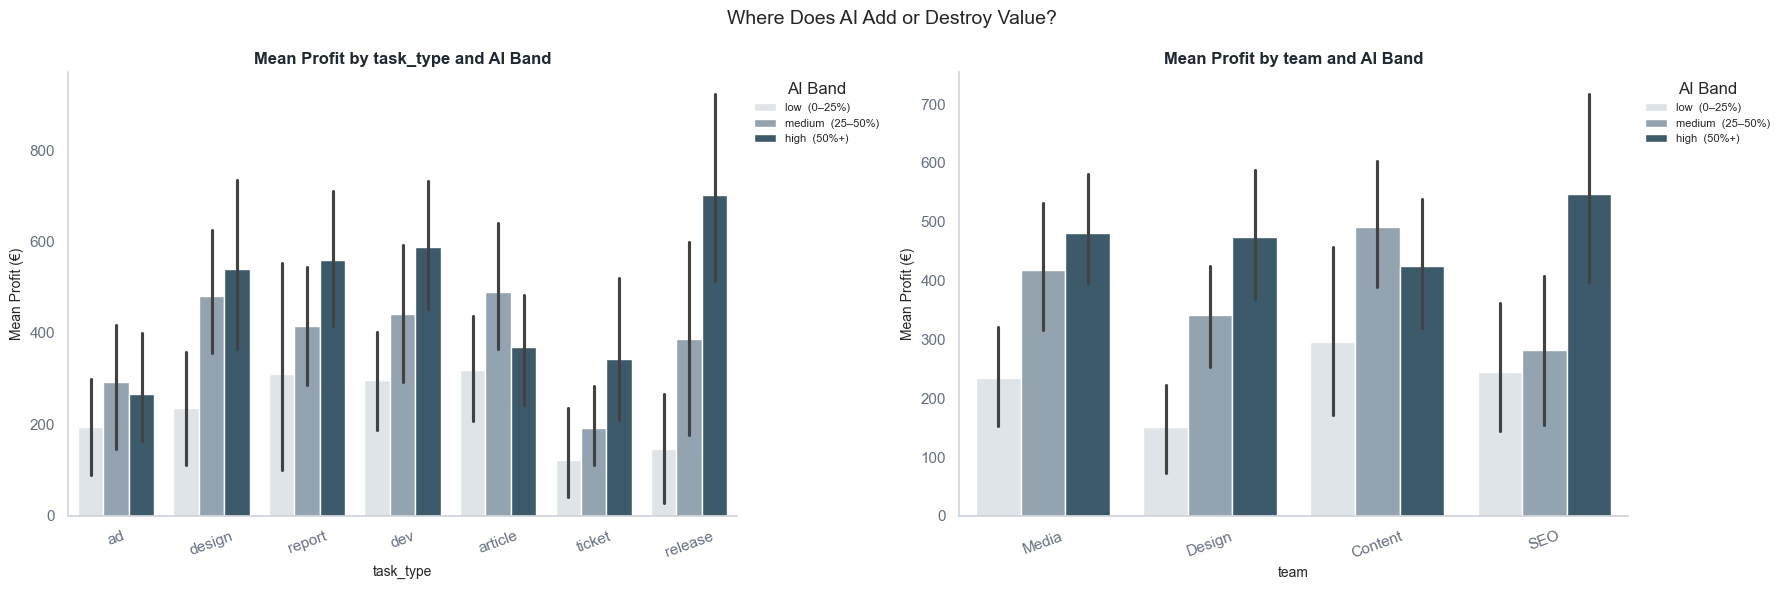

In [261]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, seg in zip(axes, ['task_type', 'team']):
    sns.barplot(
        data=df.dropna(subset=['ai_band']),
        x=seg, y='profit',
        hue='ai_band',
        hue_order=band_order,
        palette=band_palette,
        estimator='mean',
        errorbar=('ci', 95),
        ax=ax
    )
    ax.set_title(f'Mean Profit by {seg} and AI Band')
    ax.set_xlabel(seg)
    ax.set_ylabel('Mean Profit (€)')
    ax.tick_params(axis='x', labelrotation=20)
    ax.axhline(0, color=MUTED, linewidth=1, linestyle='--')
    ax.legend(title='AI Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    finish_ax(ax)

plt.suptitle('Where Does AI Add or Destroy Value?', fontsize=14)
plt.tight_layout()
plt.show()


**`article` is the only task type with an inverted-U pattern**: profit peaks in the medium band (€490) and falls in the high band (€370) — too much AI on articles degrades the outcome. All other task types benefit monotonically, with `release` (€146→€701) and `dev` (€296→€587) showing the strongest gains. At the team level the pattern is similar but less pronounced — no team shows a clear reversal.

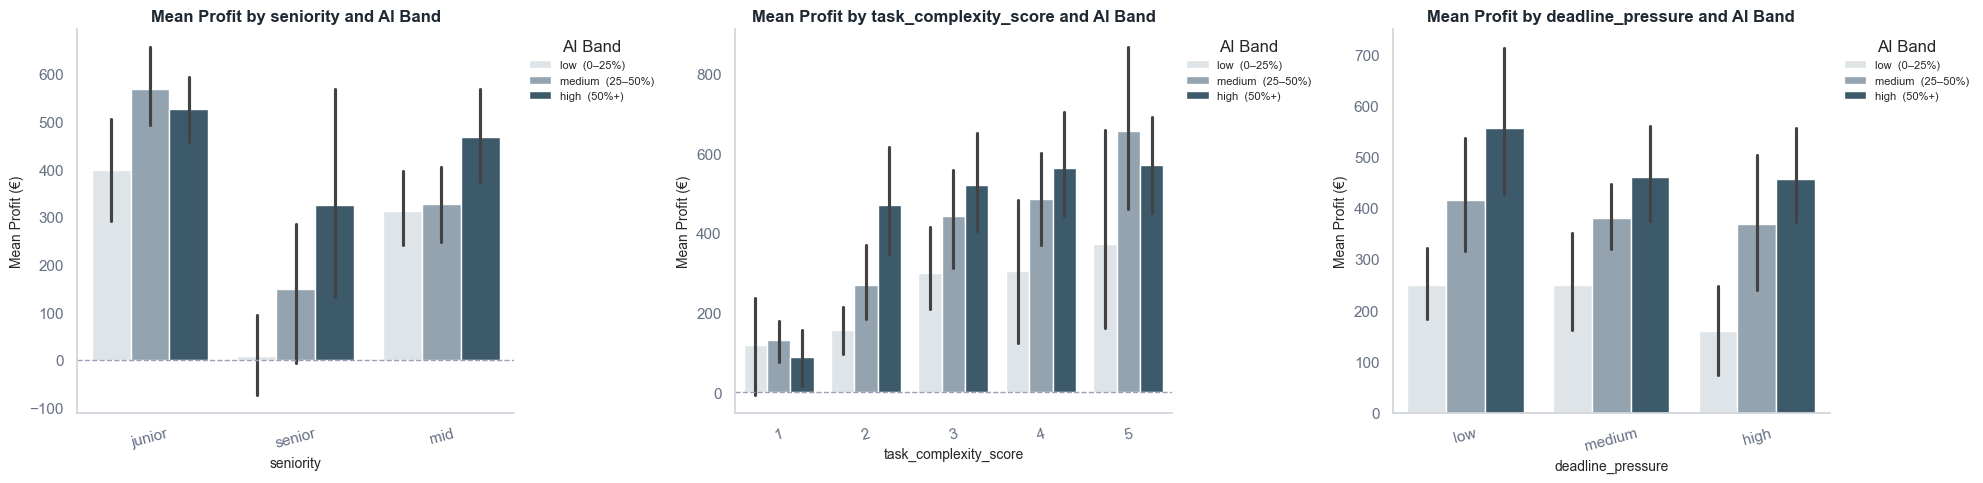

In [262]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, seg in zip(axes, ['seniority', 'task_complexity_score', 'deadline_pressure']):
    sns.barplot(
        data=df.dropna(subset=['ai_band']),
        x=seg, y='profit',
        hue='ai_band',
        hue_order=band_order,
        palette=band_palette,
        estimator='mean',
        errorbar=('ci', 95),
        ax=ax
    )
    ax.set_title(f'Mean Profit by {seg} and AI Band')
    ax.set_xlabel(seg)
    ax.set_ylabel('Mean Profit (€)')
    ax.tick_params(axis='x', labelrotation=15)
    ax.axhline(0, color=MUTED, linewidth=1, linestyle='--')
    ax.legend(title='AI Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    finish_ax(ax)

plt.tight_layout()
plt.show()


**Seniority**: juniors peak in the medium band (€568) and fall in the high band (€525); seniors grow monotonically (€9→€325) — consistent with the over-reliance hypothesis for junior contributors. **Complexity**: tasks at complexity 1 (simplest) decline at high AI (€118→€131→€89), and complexity 5 stalls (€373→€656→€569) — suggesting high AI hurts trivial tasks (no value to extract) and very complex ones (too much context to delegate). The sweet spot is complexity 3–4.

### Pricing Model — Is Hourly Less Sustainable with High AI? (Q5)

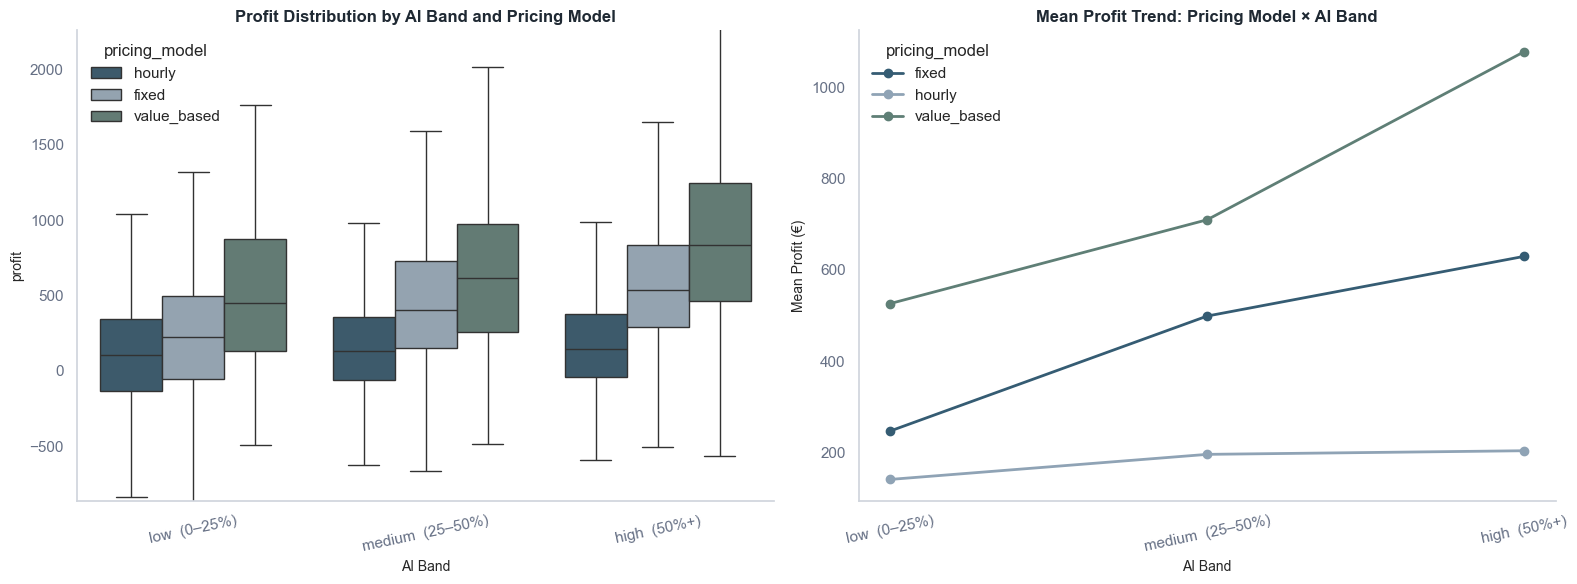

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lo, hi = df['profit'].quantile(0.02), df['profit'].quantile(0.98)

# Boxplot: profit by ai_band split by pricing_model
sns.boxplot(
    data=df.dropna(subset=['ai_band']),
    x='ai_band', y='profit',
    hue='pricing_model',
    order=band_order,
    showfliers=False,
    ax=axes[0]
)
axes[0].set_ylim(lo, hi)
axes[0].set_title('Profit Distribution by AI Band and Pricing Model')
axes[0].set_xlabel('AI Band')
axes[0].tick_params(axis='x', labelrotation=12)
finish_ax(axes[0])

# Line: mean profit trend by pricing model across bands
mean_profit = (
    df.dropna(subset=['ai_band'])
    .groupby(['pricing_model', 'ai_band'], observed=True)['profit']
    .mean()
    .unstack('pricing_model')
    .reindex(band_order)
)
mean_profit.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Mean Profit Trend: Pricing Model × AI Band')
axes[1].set_xlabel('AI Band')
axes[1].set_ylabel('Mean Profit (€)')
axes[1].tick_params(axis='x', labelrotation=12)
finish_ax(axes[1])

plt.tight_layout()
plt.show()


Pricing model is the strongest moderator: with `fixed`, profit grows from €248 to €630 across bands; with `hourly` it plateaus at €204, with almost no gain from medium to high (+€55 vs +€251 for fixed). This confirms the hypothesis — on hourly contracts, efficiency gains go to the client, not the agency. `value_based` shows the highest return (€1,077 at high AI) but is the least frequent model.

### Correlation Heatmap

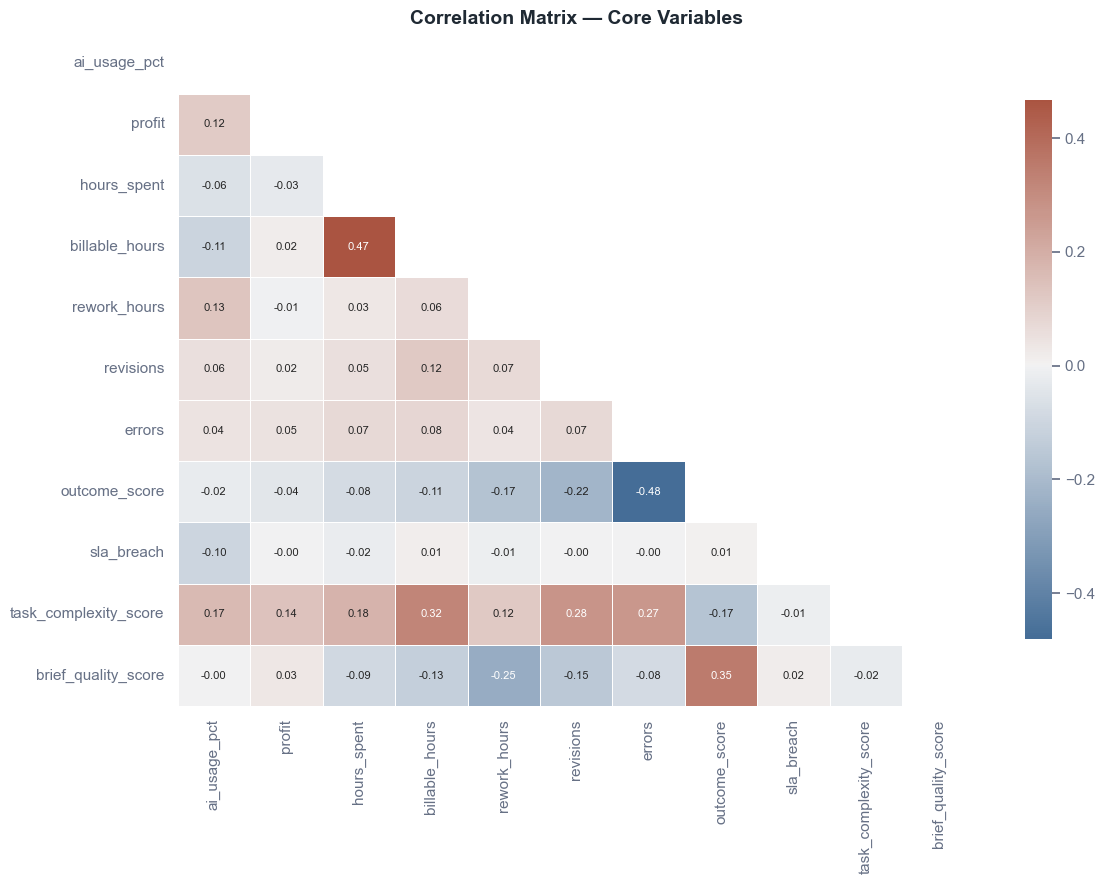

In [264]:
corr_vars = ['ai_usage_pct', 'profit', 'hours_spent', 'billable_hours',
             'rework_hours', 'revisions', 'errors', 'outcome_score',
             'sla_breach', 'task_complexity_score', 'brief_quality_score']

corr = df[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap=heatmap_cmap,
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Core Variables', fontsize=14)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


`ai_usage_pct` has weak raw correlations with all variables (strongest: +0.13 with `rework_hours`, +0.12 with `profit`). The absence of strong correlations does not mean the effect is absent — it signals that AI's impact is **conditional on context** (task type, seniority, pricing model) and not visible at the aggregate level. Note the expected high collinearity between `hours_spent` and `billable_hours`, which will need to be managed in the regression models.

### Time Trends — Monthly AI Usage and Profit

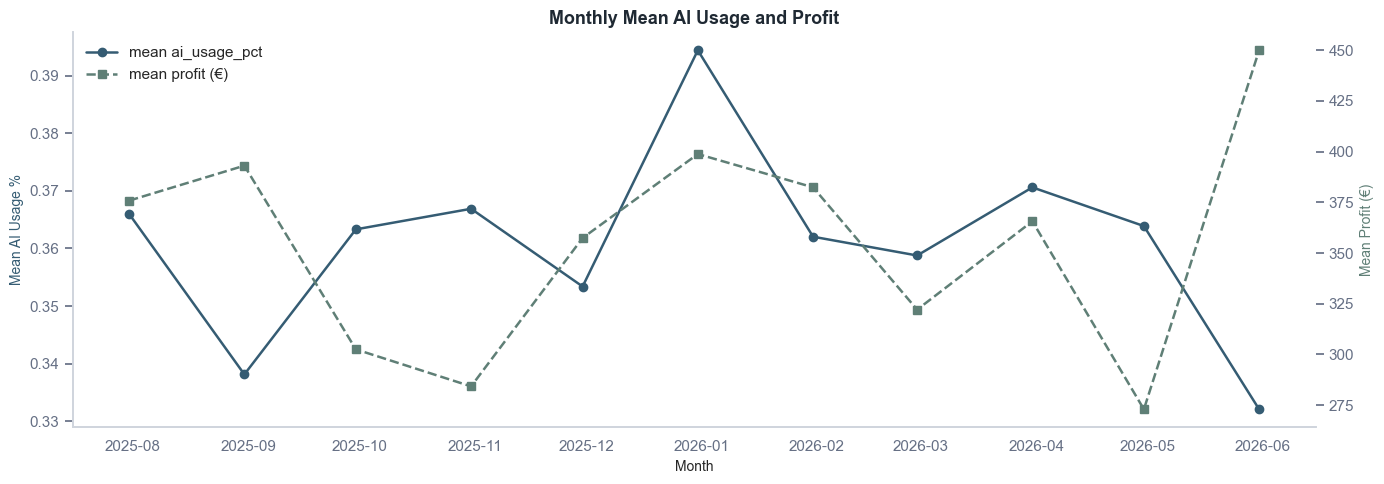

In [265]:
import pandas as pd
_freq = 'ME' if pd.__version__ >= '2.2' else 'M'

df_time = (
    df.dropna(subset=['ai_usage_pct'])
    .set_index('created_at')
    .resample(_freq)[['ai_usage_pct', 'profit']]
    .mean()
    .dropna()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df_time.index, df_time['ai_usage_pct'], color=PRIMARY, marker='o',
         linewidth=1.8, label='mean ai_usage_pct')
ax2.plot(df_time.index, df_time['profit'], color=ACCENT, marker='s',
         linewidth=1.8, linestyle='--', label='mean profit (€)')

ax1.set_ylabel('Mean AI Usage %', color=PRIMARY)
ax2.set_ylabel('Mean Profit (€)', color=ACCENT)
ax1.set_xlabel('Month')
ax1.set_title('Monthly Mean AI Usage and Profit', fontsize=13)

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')
finish_ax(ax1)
sns.despine(ax=ax2, top=True, right=True)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The time trend shows whether AI adoption grew over the observed period and whether profit followed the same direction. A divergence between the two series in the final months would be a warning sign: if AI usage is rising but profit is not keeping pace, the positive effect seen in the band analysis may be saturating or reversing over time.

### Scope Changes 

14% of tasks had scope changes during execution.

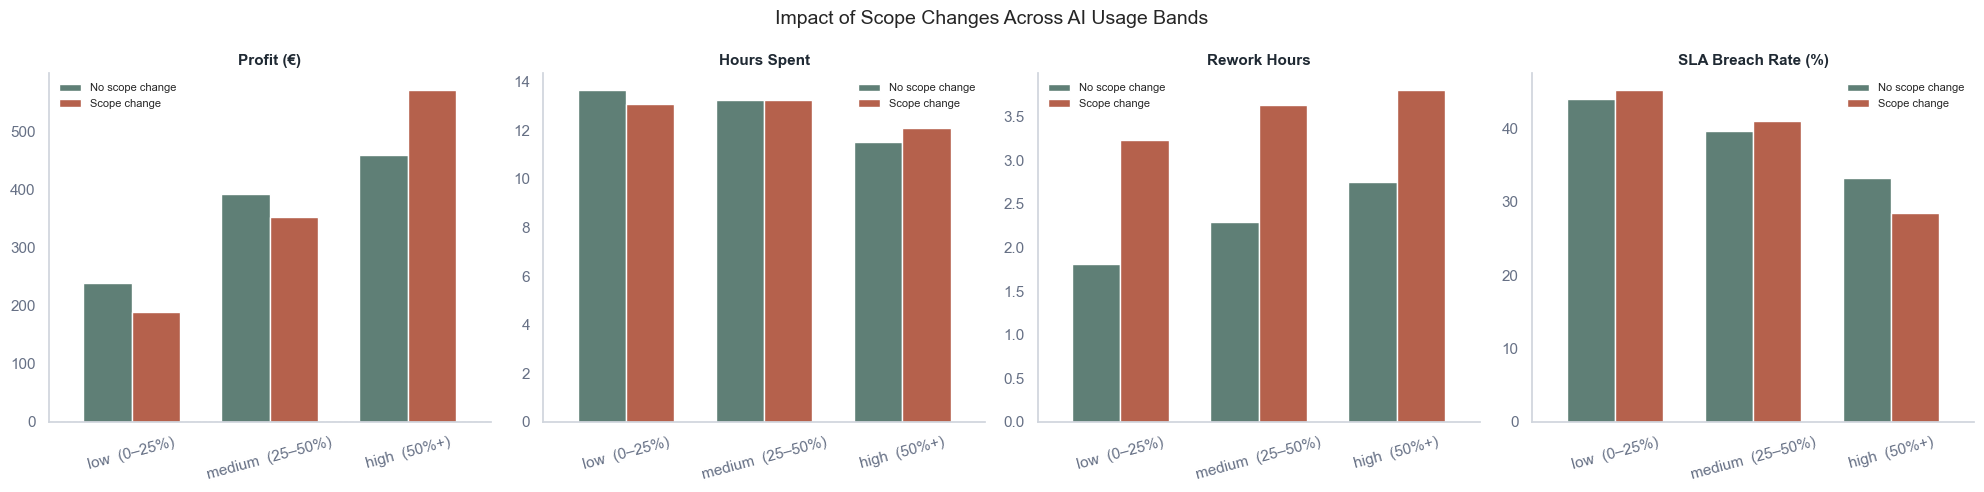

In [266]:
df_scope = df.dropna(subset=['ai_band']).copy()
df_scope['scope_label'] = df_scope['scope_change_flag'].map({0: 'No scope change', 1: 'Scope change'})

metrics = ['profit', 'hours_spent', 'rework_hours', 'sla_breach']
titles  = ['Profit (€)', 'Hours Spent', 'Rework Hours', 'SLA Breach Rate (%)']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var, title in zip(axes, metrics, titles):
    pivot = (
        df_scope.groupby(['ai_band', 'scope_label'], observed=True)[var]
        .mean()
        .unstack('scope_label')
        .reindex(band_order)
    )
    if var == 'sla_breach':
        pivot = pivot * 100

    pivot.plot.bar(
        ax=ax, color=[ACCENT, RISK], edgecolor='white', width=0.7
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=15)
    ax.legend(fontsize=8, loc='best')
    if var == 'profit':
        ax.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
    finish_ax(ax)

plt.suptitle('Impact of Scope Changes Across AI Usage Bands', fontsize=14)
plt.tight_layout()
plt.show()

Scope changes consistently increase hours spent, rework hours, and SLA breach rates across all AI bands. The more relevant finding is an **interaction effect**: rework hours increase disproportionately when scope changes occur in the high AI band, suggesting that AI-assisted workflows may be less resilient to mid-flight requirement shifts.